¿Qué variables parecen diferenciar a fumadores de no fumadores?

1. Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/smoking_prediction.csv")

2. Recordatorio de la variable objetivo

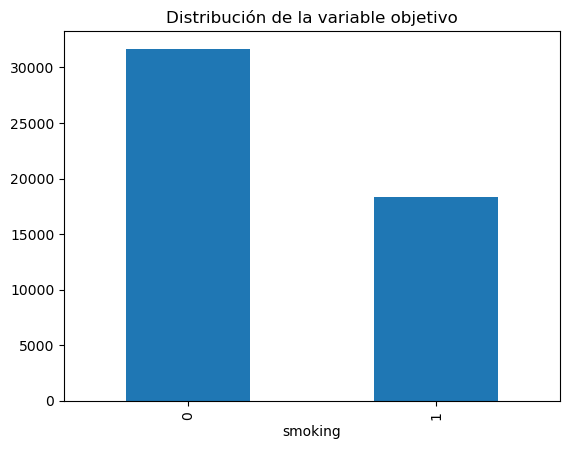

In [3]:
df["smoking"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.show()

3. Análisis de variables categóricas (gender y tartar)

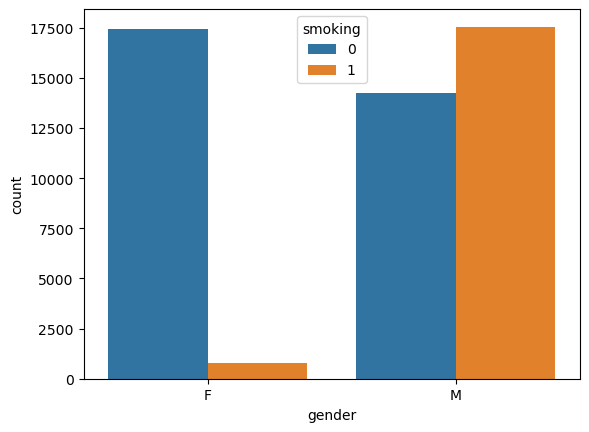

In [4]:
#Gender vs Smoking

sns.countplot(
    data=df,
    x="gender",
    hue="smoking"
)
plt.show()

#¿Fuman más los hombres o las mujeres?

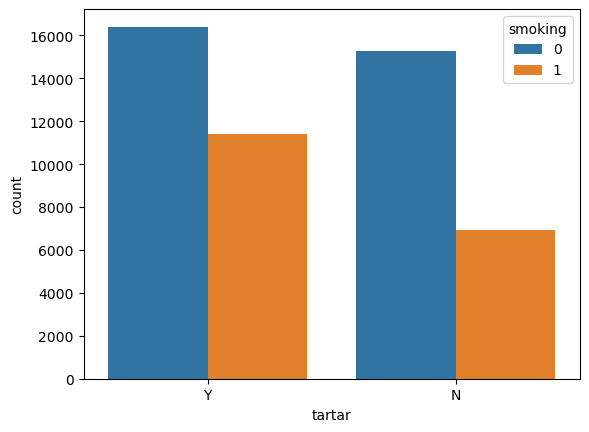

In [5]:
# Tartar vs Smoking

sns.countplot(
    data=df,
    x="tartar",
    hue="smoking"
)
plt.show()

#¿Las personas con sarro dental fuman más?

4. Variables numéricas

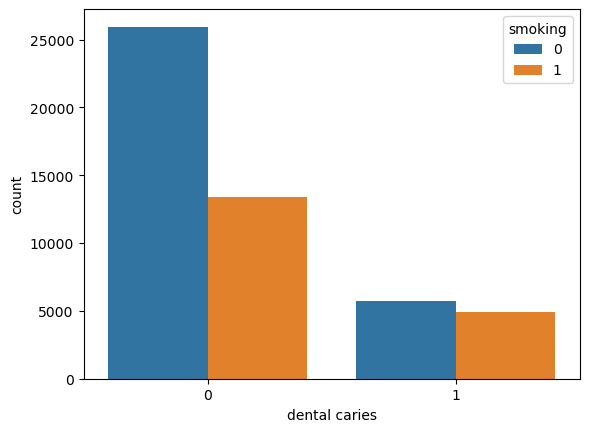

In [19]:
# Dental Caries vs Smoking

sns.countplot(
    data=df,
    x="dental caries",
    hue="smoking"
)
plt.show()

#¿Las personas que fuman tienen más caries?
# Se observa que cuando las personas fuman aumenta probabilidad de tener caries
# En cuanto a cantidades hay que tener en cuenta que partimos de un DS con muchos mas NO FUMADORES.

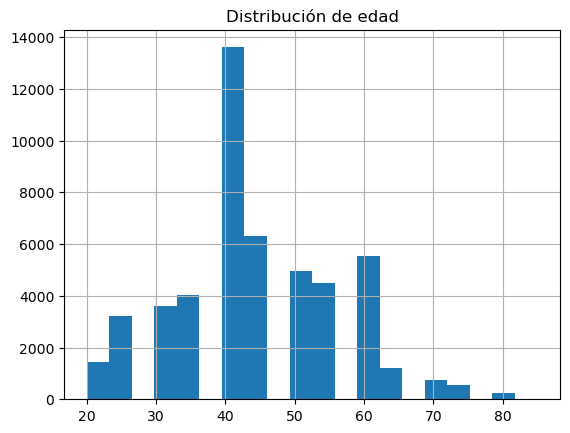

In [6]:
numericas = df.select_dtypes(
    include=["int64", "float64"]
).columns

df["age"].hist(bins=20)
plt.title("Distribución de edad")
plt.show()

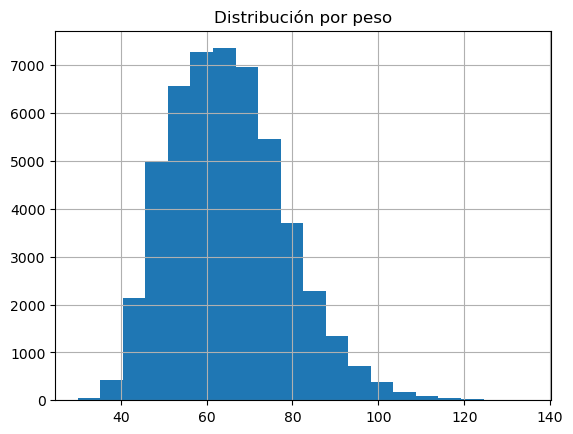

In [7]:
df["weight(kg)"].hist(bins=20)
plt.title("Distribución por peso")
plt.show()

5. Comparación fumadores vs no fumadores

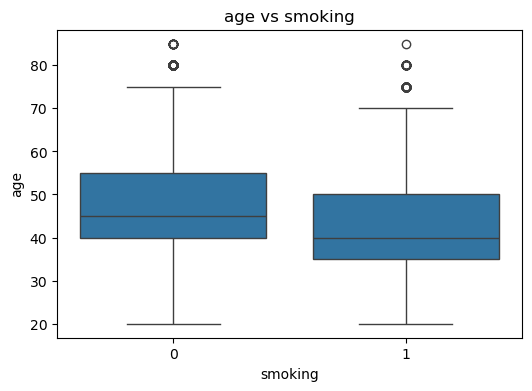

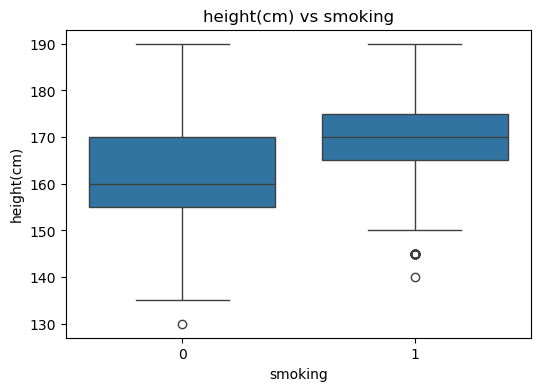

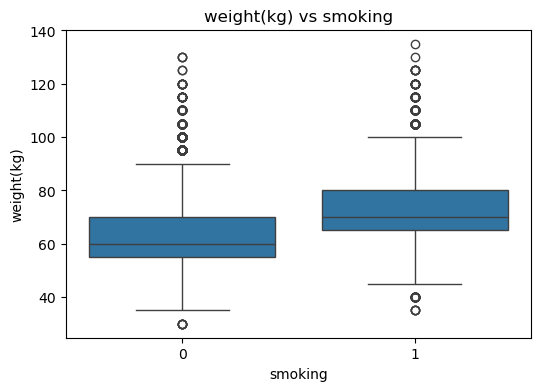

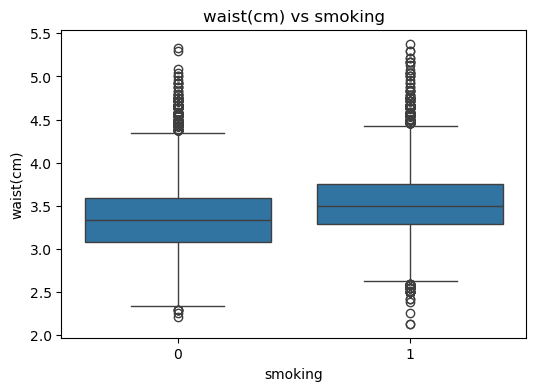

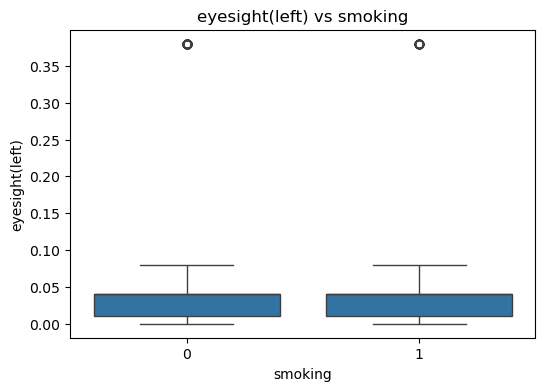

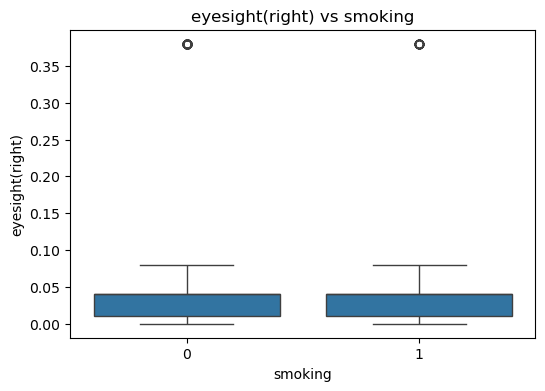

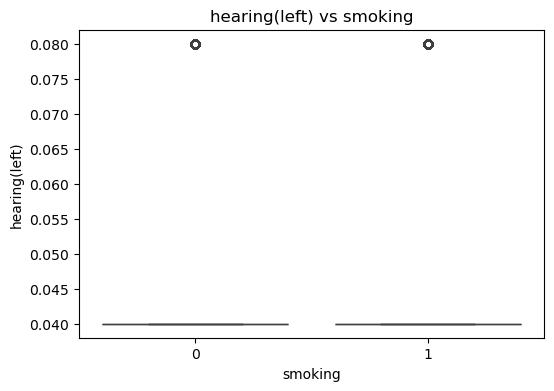

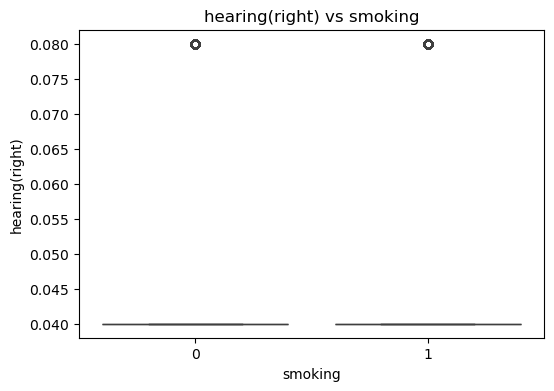

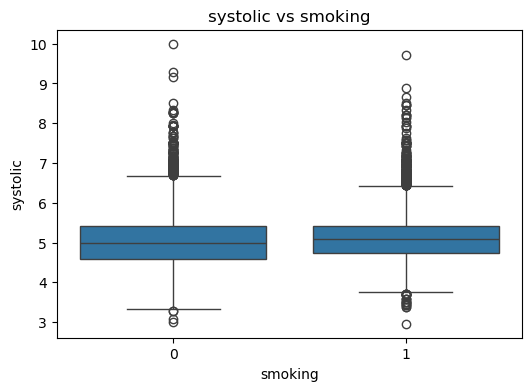

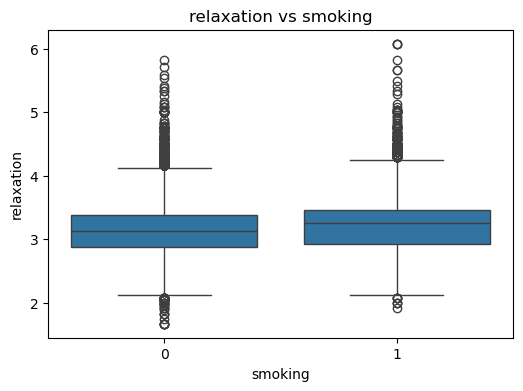

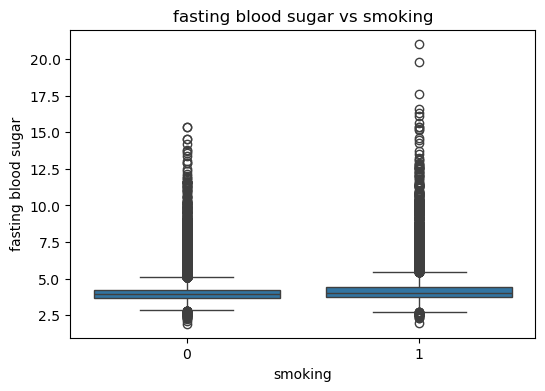

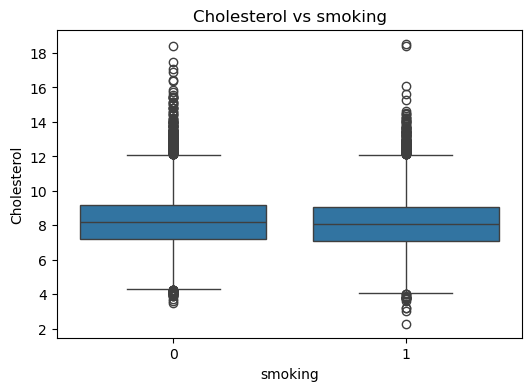

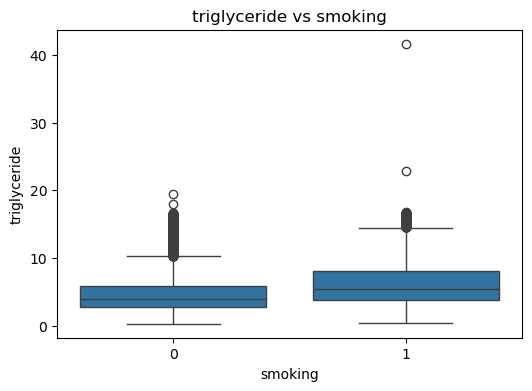

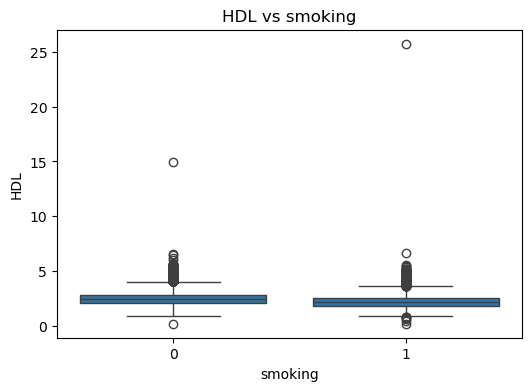

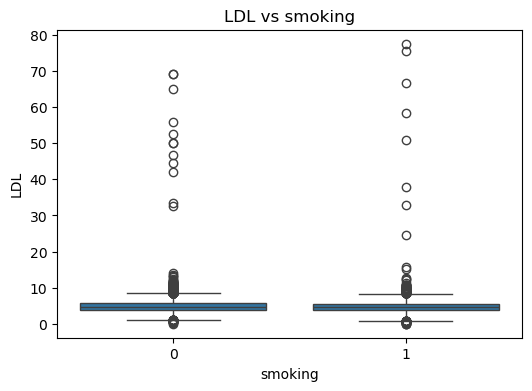

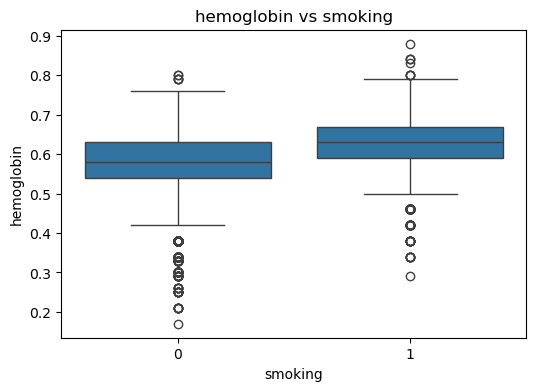

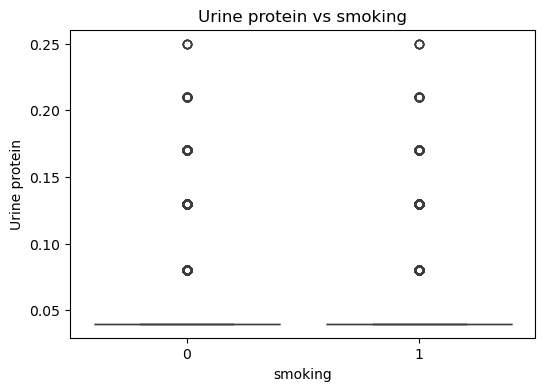

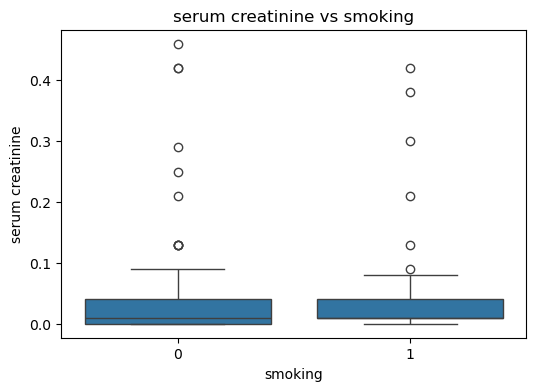

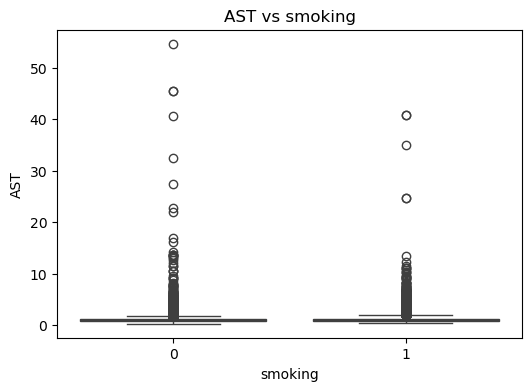

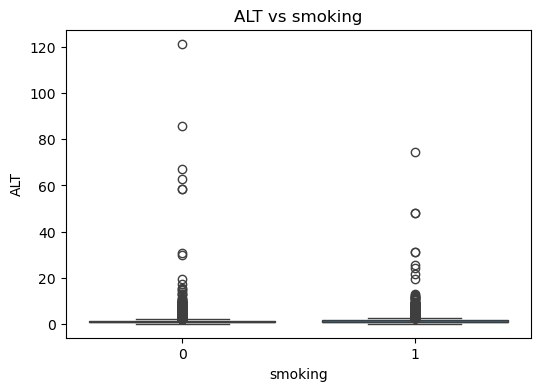

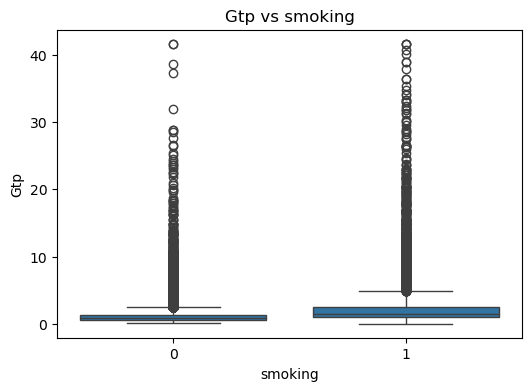

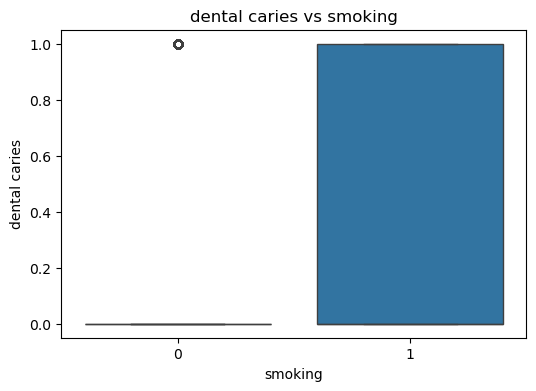

In [18]:
for col in numericas:
    
    if col not in ["ID", "smoking"]:
        
        plt.figure(figsize=(6,4))
        
        sns.boxplot(
            data=df,
            x="smoking",
            y=col
        )
        
        plt.title(f"{col} vs smoking")
        plt.show()

#Dental caries por más que es numérica se comporta como una categórica (aplica 0 y 1 si no tienen o tienen caries)


In [25]:
pd.crosstab(
    df["dental caries"],
    df["smoking"],
    normalize="index"
) * 100

smoking,0,1
dental caries,,
0,65.943981,34.056019
1,53.734985,46.265015


In [22]:
corr["smoking"].sort_values(
    key=abs,
    ascending=False
)

smoking                1.000000
hemoglobin             0.397073
height(cm)             0.396284
weight(kg)             0.301405
triglyceride           0.251112
Gtp                    0.235969
serum creatinine       0.224815
waist(cm)              0.224611
HDL                   -0.177006
age                   -0.163722
relaxation             0.108101
dental caries          0.103757
fasting blood sugar    0.098112
ALT                    0.094129
systolic               0.073198
eyesight(right)        0.073018
eyesight(left)         0.070211
AST                    0.057354
LDL                   -0.045708
Cholesterol           -0.030015
hearing(left)         -0.021871
hearing(right)        -0.017727
Urine protein          0.015423
ID                     0.012211
Name: smoking, dtype: float64

In [23]:
pd.crosstab(
    df["gender"],
    df["smoking"],
    normalize="index"
) * 100

smoking,0,1
gender,,
F,95.723540,4.276460
M,44.783539,55.216461


In [24]:
pd.crosstab(
    df["tartar"],
    df["smoking"],
    normalize="index"
) * 100

smoking,0,1
tartar,,
N,68.740714,31.259286
Y,59.026953,40.973047


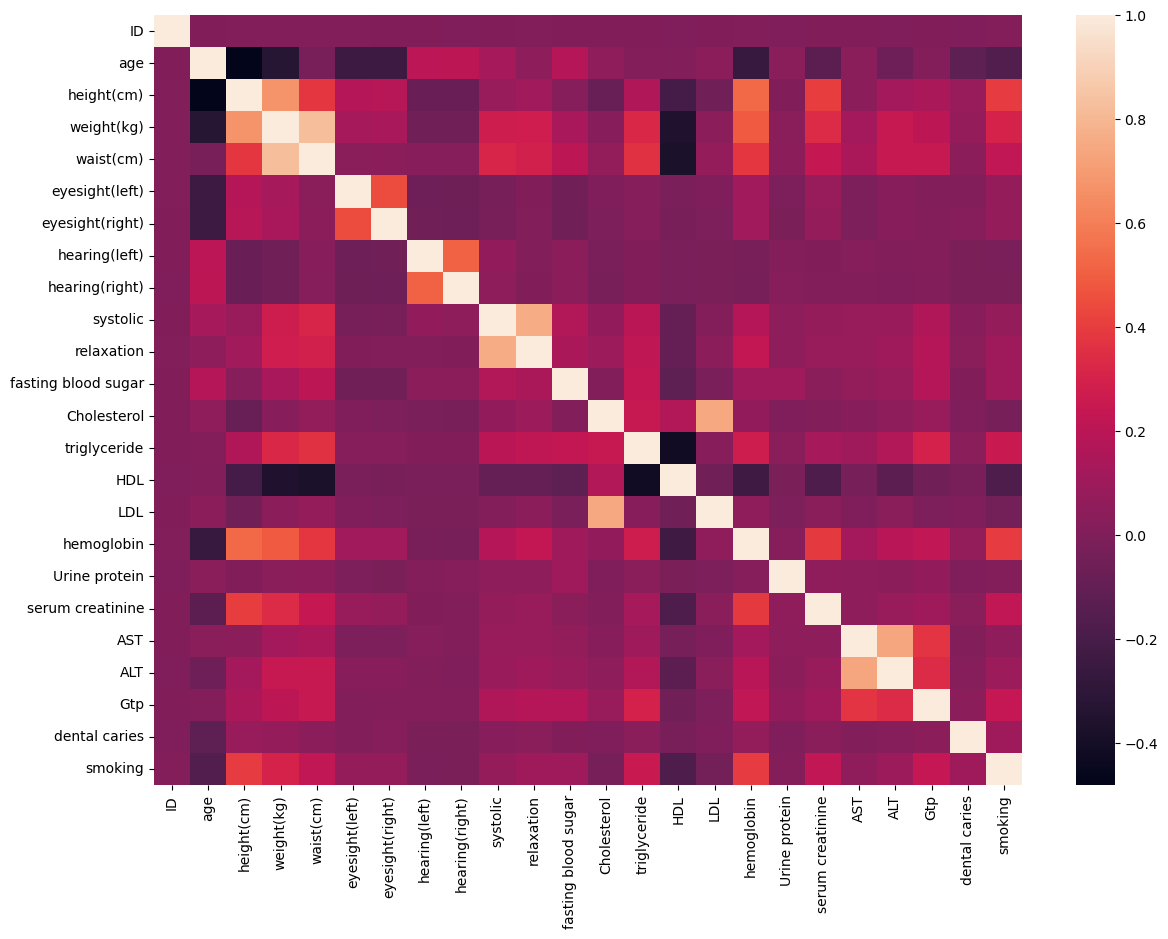

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr)
plt.show()

Conclusiones

El análisis exploratorio permitió identificar variables potencialmente relevantes para la predicción del tabaquismo.

La variable categórica con mayor asociación observada fue gender, donde el 55,2% de los hombres son fumadores frente al 4,3% de las mujeres.

Entre las variables numéricas, hemoglobin presentó la mayor correlación positiva con la variable objetivo (0,397), seguida por height(cm), weight(kg), triglyceride y Gtp.

También se observó una asociación positiva entre el tabaquismo y la presencia de problemas dentales (dental caries y tartar), aunque de menor magnitud que la observada para el género.

El mapa de correlación permitió identificar relaciones importantes entre algunas variables explicativas, aunque no se detectaron correlaciones tan elevadas como para justificar su eliminación en esta etapa.

En general, los resultados sugieren que la predicción del tabaquismo probablemente dependa de la combinación de múltiples variables más que de un único predictor dominante.



Próximos pasos para el preprocesamiento

A partir de los resultados obtenidos durante el análisis exploratorio, se planifican las siguientes acciones para la etapa de preprocesamiento:

Eliminar la variable ID, ya que actúa como un identificador único y no aporta valor predictivo.
Eliminar la variable oral, debido a que presenta un único valor (Y) en todos los registros y no contiene información útil para el modelo.
Codificar las variables categóricas gender y tartar para que puedan ser utilizadas por los algoritmos de Machine Learning.
Separar la variable objetivo (smoking) del conjunto de variables predictoras.
Dividir los datos en conjuntos de entrenamiento y test.
Construir un pipeline de preprocesamiento reproducible que pueda reutilizarse posteriormente sobre el conjunto de datos sin etiquetar.